# Jack Gurevitch: Breakout Power Season

Cardinals 1B, age 22, 2026. Low-A Palm Beach (Florida State League), High-A Peoria (Midwest League), Double-A Springfield (Texas League).

Run top to bottom from this folder. It rebuilds the pitch tables, the rank tables, and all six `../figures/gurevitch_*.png` charts. The code lives in the `.py` files next to this notebook; each cell calls one of them.

In [1]:
import pandas as pd
from IPython.display import Image, display

import statsapi_pull, gurevitch_tables, ranks, charts

pd.set_option("display.width", 250, "display.max_columns", 30, "display.max_colwidth", 70, "display.max_rows", 200)

## 1. Pitch data (MLB Stats API)

Every pitch he saw in 2026, from each game's live feed. The saved CSV is used if it's already here; delete it to pull again. Only the Low-A games have pitch tracking (velo, exit velo).

In [2]:
if statsapi_pull.OUT.exists():
    pitches = pd.read_csv(statsapi_pull.OUT)
    print(f"using saved {statsapi_pull.OUT.name}: {len(pitches)} pitches, {pitches.game_pk.nunique()} games")
else:
    pitches = statsapi_pull.pull()
pitches.groupby(["level", "game_type"]).agg(games=("game_pk", "nunique"), pitches=("game_pk", "size"), first=("game_date", "min"), last=("game_date", "max"))

using saved gurevitch_pitches_2026_statsapi.csv: 2136 pitches, 124 games


games  pitches       first        last
level    game_type                                        
Double-A L              2       29  2026-09-15  2026-09-17
         R             32      532  2026-08-04  2026-09-13
         W              3       49  2026-09-20  2026-09-23
High-A   R             59     1015  2026-05-12  2026-08-01
Low-A    R             28      511  2026-04-02  2026-05-10

## 2. Pitch tables

Tables 1-3 are Florida State League (Low-A) only. ⚠ = under 20 PA or pitches.

In [3]:
tables = gurevitch_tables.build_tables()

Florida State League (Low-A): pitch type tracked on 496 of 511 pitches; 65 batted balls with exit velo.   ⚠ = under 20 PA or pitches

1. BY PITCH GROUP, Florida State League (results = PAs ending on that pitch group)  -> pitch_table1_by_pitch_group_2026.csv
         Pitches Swing% Whiff% BBE w/ EV Avg EV Max EV Hard-hit% PA ending   AVG   SLG HR
Fastball     274  53.3%  24.7%        39   96.4  115.0     69.2%        70  .291  .582  4
Breaking     132  56.1%  41.9%      17 ⚠   93.0  109.5     58.8%        39  .200  .400  1
Offspeed      90  34.4%  41.9%       9 ⚠   92.3  108.8     33.3%      15 ⚠  .385  .769  1

2. FASTBALLS BY VELOCITY, Florida State League  -> pitch_table2_fastball_velo_2026.csv
         Pitches Swing% Whiff% BBE w/ EV Avg EV Max EV Hard-hit% PA ending   AVG   SLG HR
93+ mph      138  54.3%  26.7%      13 ⚠   98.7  115.0     76.9%        28  .200  .400  1
Under 93     136  52.2%  22.5%        26   95.2  111.1     65.4%        42  .367  .733  3

3. HARD-HIT BALLS (95+ 

## 3. Rank check

Every number on the charts and in the post, recomputed from the source files, with the exact comparison group.

In [4]:
check = ranks.check_claims()
check

63 of 64 match | mismatches: 1 -> rank_check_2026.csv
Not checkable from project files: 2026 MLB avg EV 88.0 mph (cached Baseball Savant Statcast); draft round, USD stats.


,where,claim,shown,recomputed,source,group,match
0,projection chart,Midwest League hitters,178,178,FanGraphs high_a_*,"Midwest League, 130+ PA",yes
1,projection chart,Midwest League minimum PA,130,130,FanGraphs high_a_*,"Midwest League, 130+ PA",yes
2,projection chart,Midwest League HR / PA / ISO,17/273/.264,17/273/.264,FanGraphs high_a_*,"Midwest League, 130+ PA",yes
3,projection chart,Midwest League HR rate rank,6 of 178,6 of 178,FanGraphs high_a_*,"Midwest League, 130+ PA",yes
4,projection chart,Midwest League ISO rank,12 of 178,12 of 178,FanGraphs high_a_*,"Midwest League, 130+ PA",yes
5,projection chart,"Midwest League medians HR/PA, ISO",2.5%/.158,2.5%/.158,FanGraphs high_a_*,"Midwest League, 130+ PA",yes
6,projection chart,Texas League hitters,154,154,FanGraphs aa_*,"Texas League, 130+ PA",yes
7,projection chart,Texas League minimum PA,130,130,FanGraphs aa_*,"Texas League, 130+ PA",yes
8,projection chart,Texas League HR / PA / ISO,9/141/.242,9/141/.242,FanGraphs aa_*,"Texas League, 130+ PA",yes
9,projection chart,Texas League HR rate rank,8 of 154,8 of 154,FanGraphs aa_*,"Texas League, 130+ PA",yes


## 4. Where he ranks top 10

Every stat in every file, in five groups: Midwest League 130+ PA, Texas League 130+ PA, each of those limited to hitters 22 or younger, and all Double-A leagues with 75+ batted balls (TJStats). `minimum_check` re-ranks him at the other minimums listed.

In [5]:
top10 = ranks.top10_scan()
top10

26 top-10 ranks -> top10_ranks_2026.csv


,group,stat,rank,of,tied_with,value,type,minimum_check,tested_minimums,his_sample
0,"Texas League, 130+ PA",HR/FB,1,154,0,0.473684,rate,holds at every tested minimum,"130,141",141 PA
1,"Texas League, age 22 or younger, 130+ PA",HR/FB,1,36,0,0.473684,rate,holds at every tested minimum,"130,141",141 PA
2,"Texas League, age 22 or younger, 130+ PA",IFFB%,1,36,0,0.052632,rate,holds at every tested minimum,"130,141",141 PA
3,"Midwest League, age 22 or younger, 130+ PA",IFFB%,2,104,0,0.039216,rate,holds at every tested minimum,"130,150,200,250",273 PA
4,"Texas League, 130+ PA",IFFB%,2,154,0,0.052632,rate,holds at every tested minimum,"130,141",141 PA
5,"Texas League, age 22 or younger, 130+ PA",Cent% (highest),2,36,0,0.320513,descriptive,holds at every tested minimum,"130,141",141 PA
6,"Midwest League, 130+ PA",IFFB%,3,178,0,0.039216,rate,holds at every tested minimum,"130,150,200,250",273 PA
7,"Midwest League, age 22 or younger, 130+ PA",HR/FB,3,104,0,0.333333,rate,holds at every tested minimum,"130,150,200,250",273 PA
8,"Texas League, age 22 or younger, 130+ PA",LD%,3,36,0,0.285714,rate,holds at every tested minimum,"130,141",141 PA
9,"Midwest League, 130+ PA",HR/FB,4,178,1,0.333333,rate,holds at every tested minimum,"130,150,200,250",273 PA


## 5. Charts

In [6]:
charts.make_all()

== projection
High-A: Midwest League: HR/PA 6.2% rank 6/178, ISO 0.264 rank 12/178
Double-A: Texas League: HR/PA 6.4% rank 8/154, ISO 0.242 rank 21/154


   layout: off-figure none | text overlaps none


   saved gurevitch_projection_2026.png
== age_power
Texas League: ISO 0.242 rank 21/154 (top 13.6%) | 76.6% of hitters older than 22
   layout: off-figure none | text overlaps none
   saved gurevitch_age_power_2026.png
== batted_ball
Texas League: HR/FB 47.4% rank 1/154 (top 0.6%) | LD% 28.6% rank 15/154 (top 9.7%)


   layout: off-figure none | text overlaps none
   saved gurevitch_batted_ball_2026.png
== power_profile
Midwest League percentiles: {'SLG': '97 (rank 7/178)', 'HR rate': '97 (rank 6/178)', 'HR/FB': '98 (rank 4/178)', 'ISO': '94 (rank 12/178)', 'OPS': '93 (rank 13/178)', 'AVG': '93 (rank 14/178)', 'wRC+': '89 (rank 20/178)'}
   layout: off-figure none | text overlaps none


   saved gurevitch_power_profile_2026.png
== line_drives
All Double-A leagues, 75+ BBE: 479 hitters | pop-up 1.3% rank 11/479 (top 2.3%) | LD 28.2% rank 50/479 (top 10.4%) | 78 batted balls
   layout: off-figure none | text overlaps none
   saved gurevitch_line_drives_2026.png
== exit_velo
Florida State League avg EV (BBE): {'Fastballs 93+ mph': '98.7 (13)', 'Fastballs under 93': '95.2 (26)', 'Breaking': '93.0 (17)', 'Offspeed': '92.3 (9)'}


   layout: off-figure none | text overlaps none
   saved gurevitch_exit_velo_2026.png


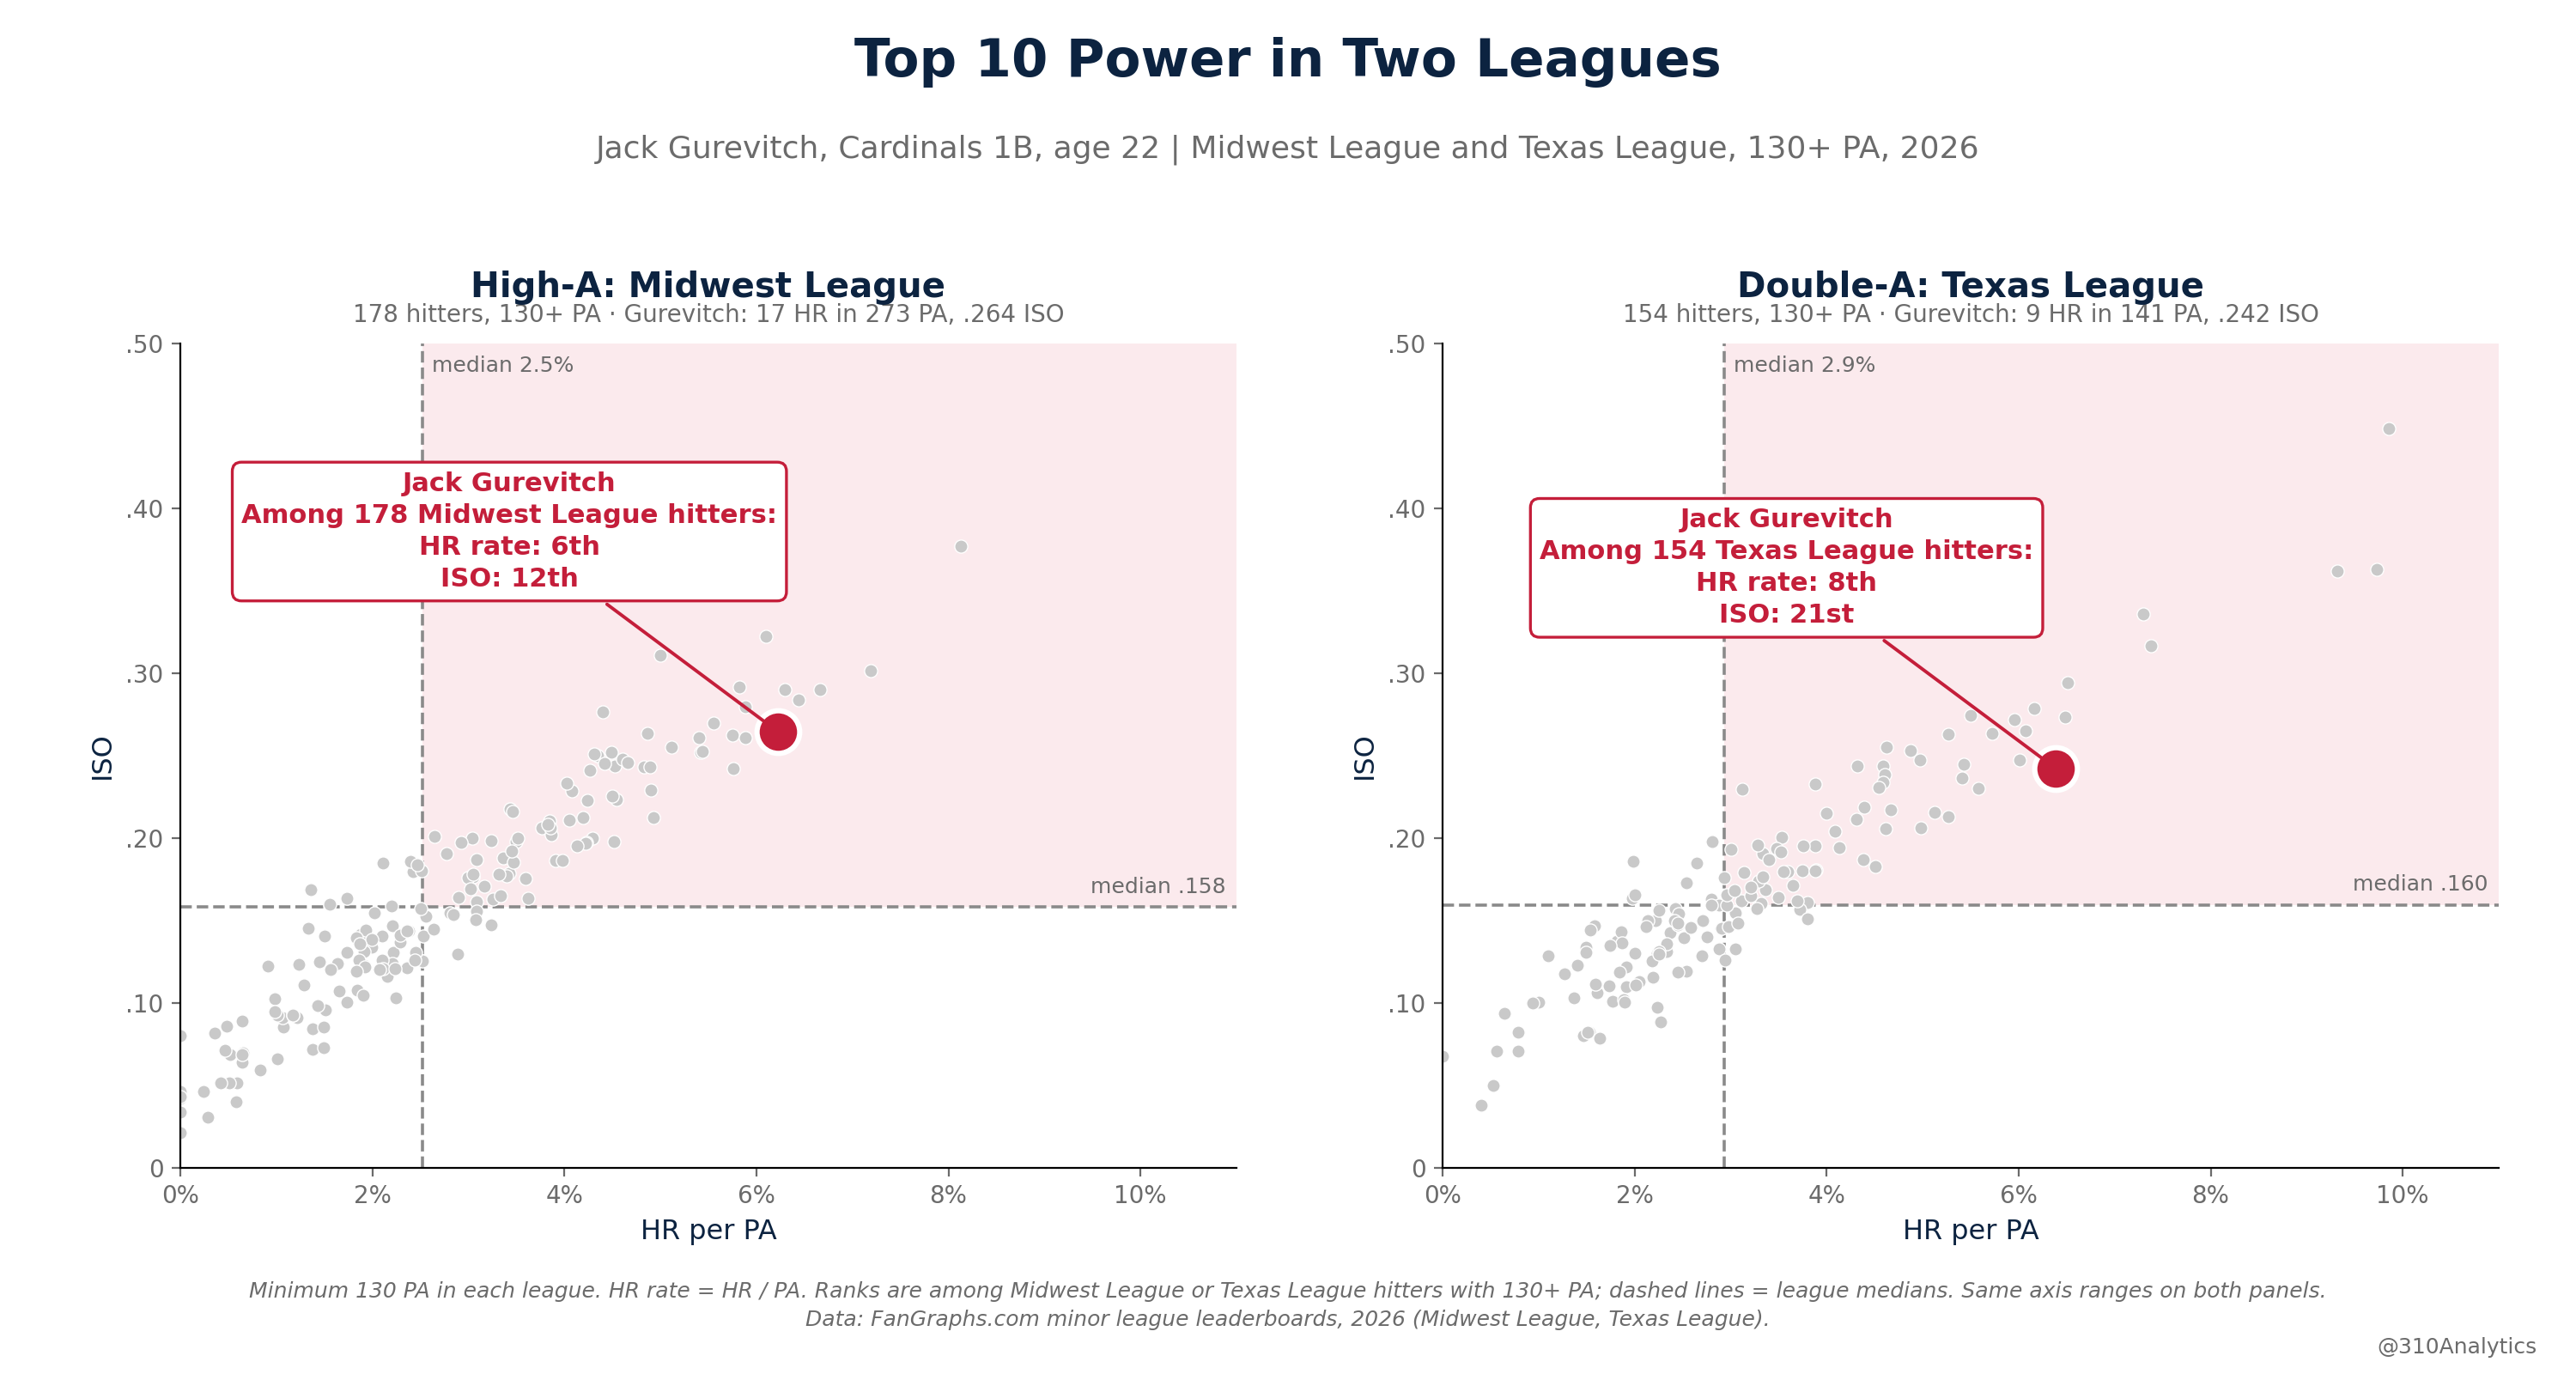

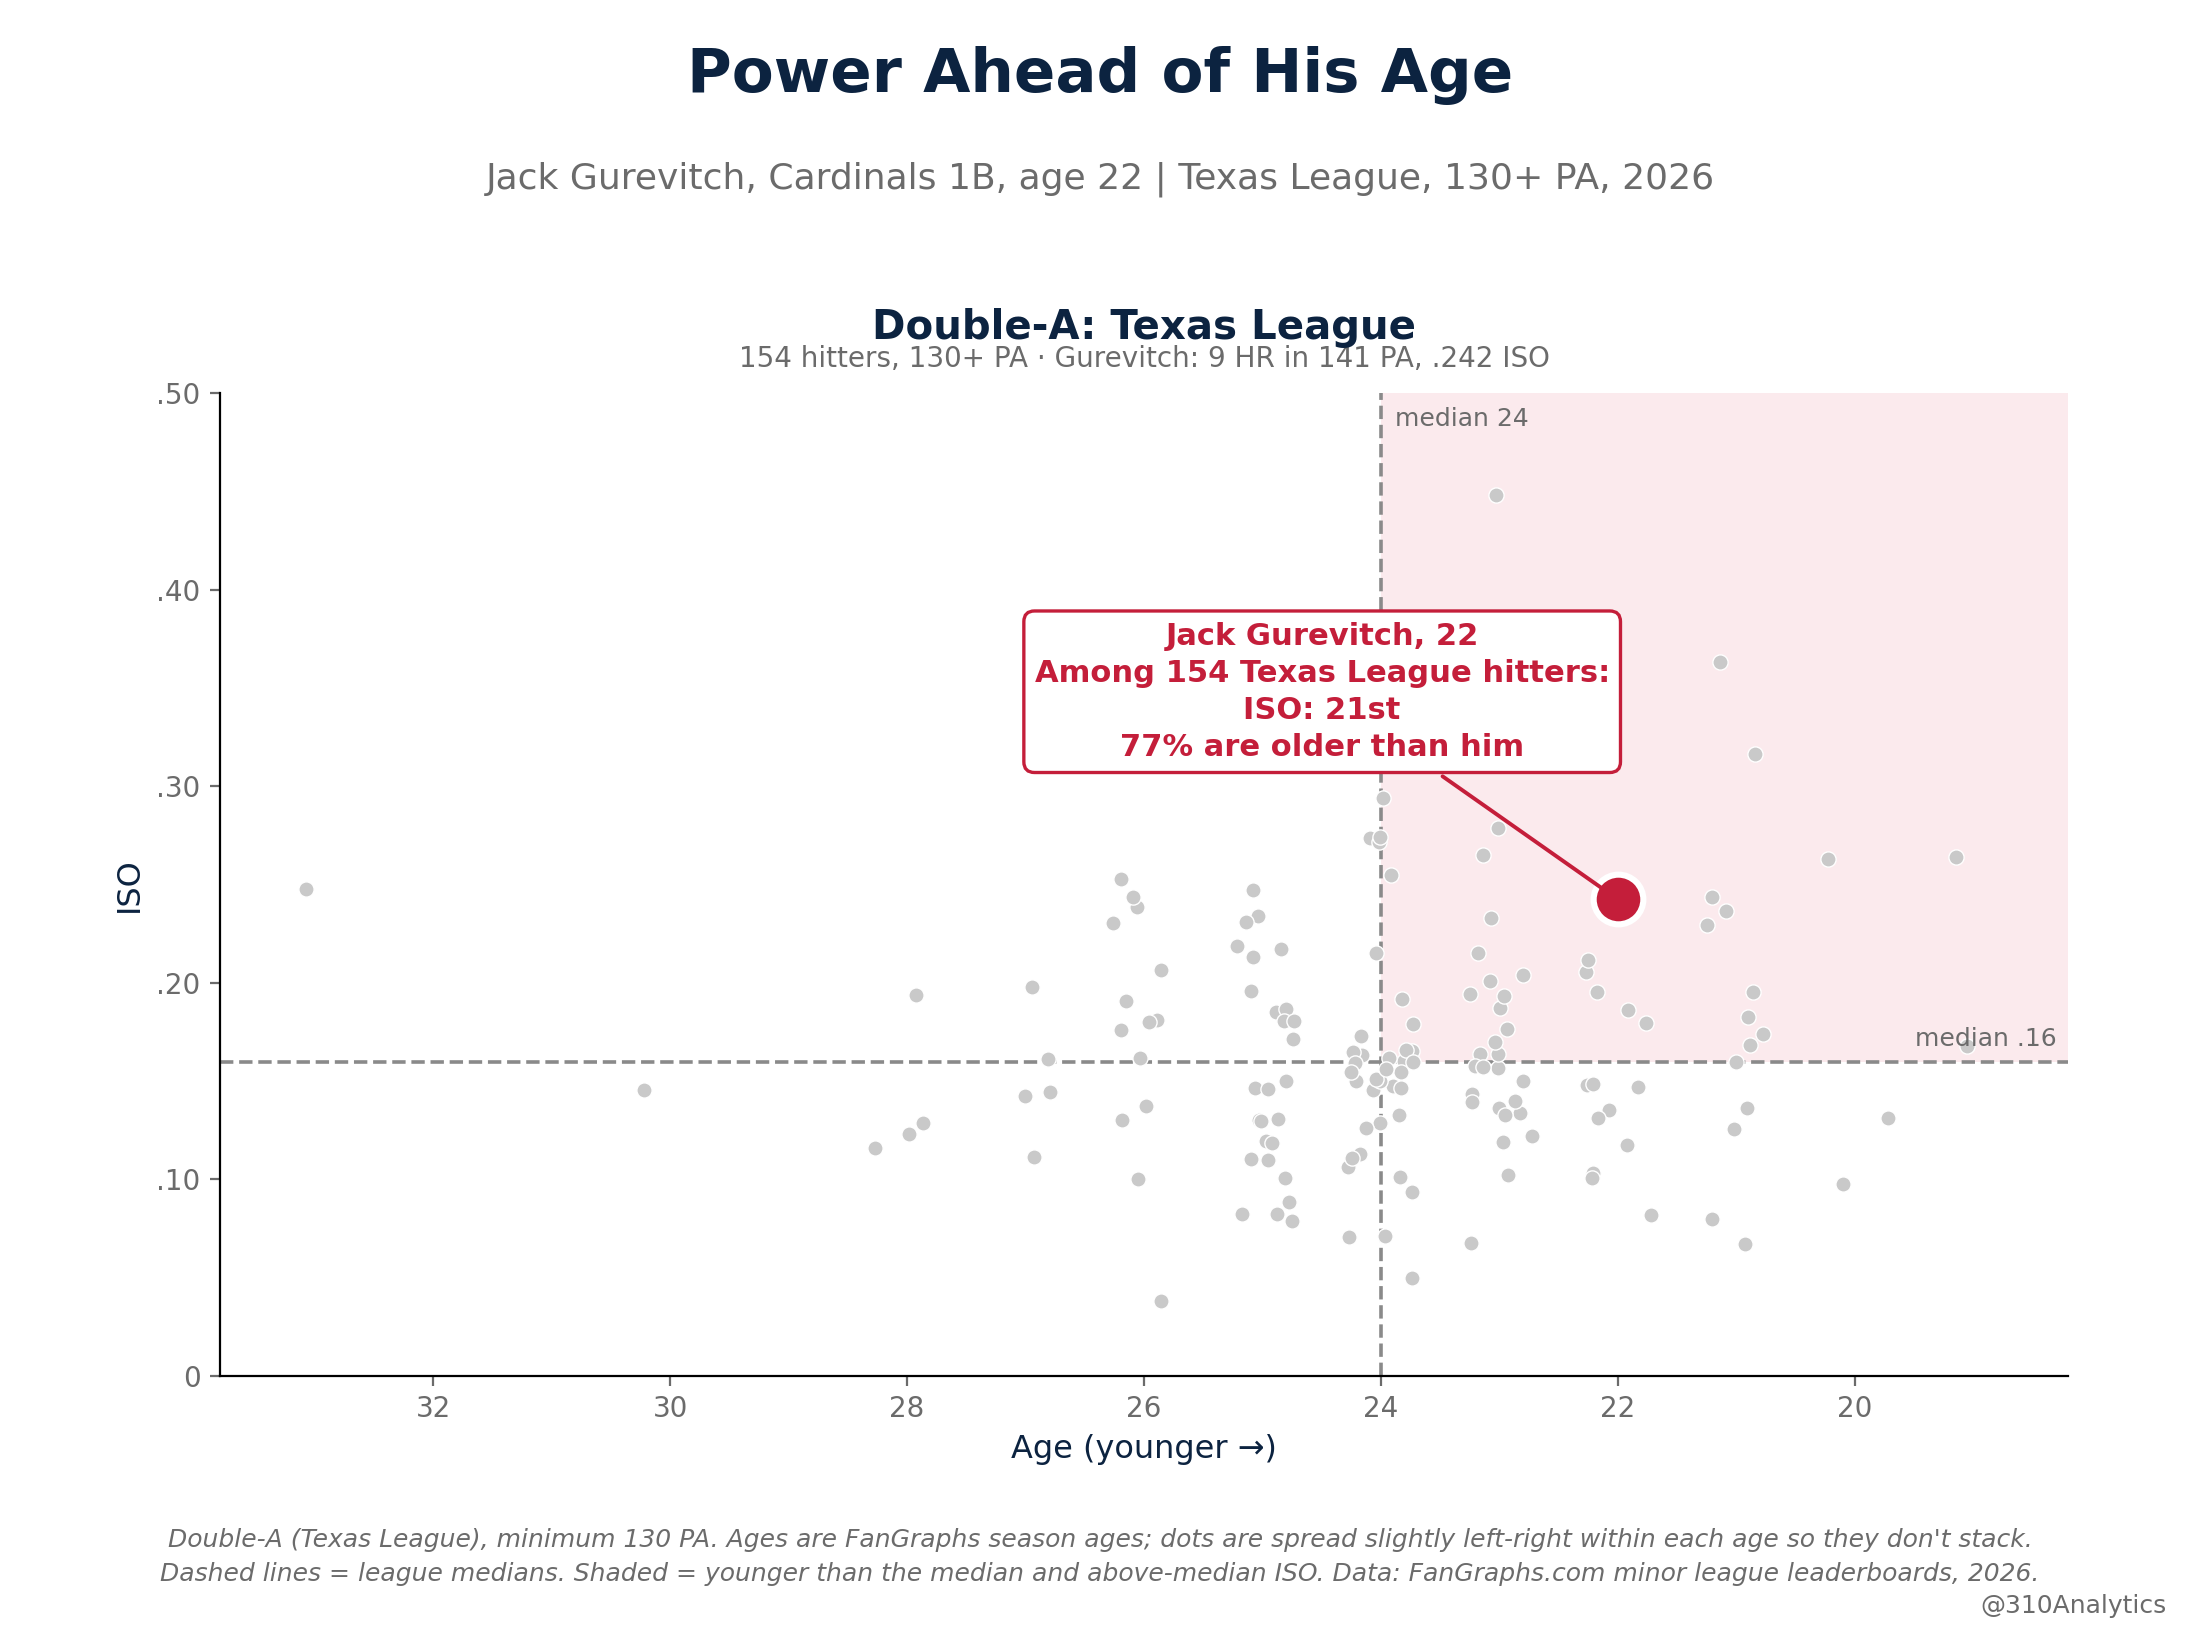

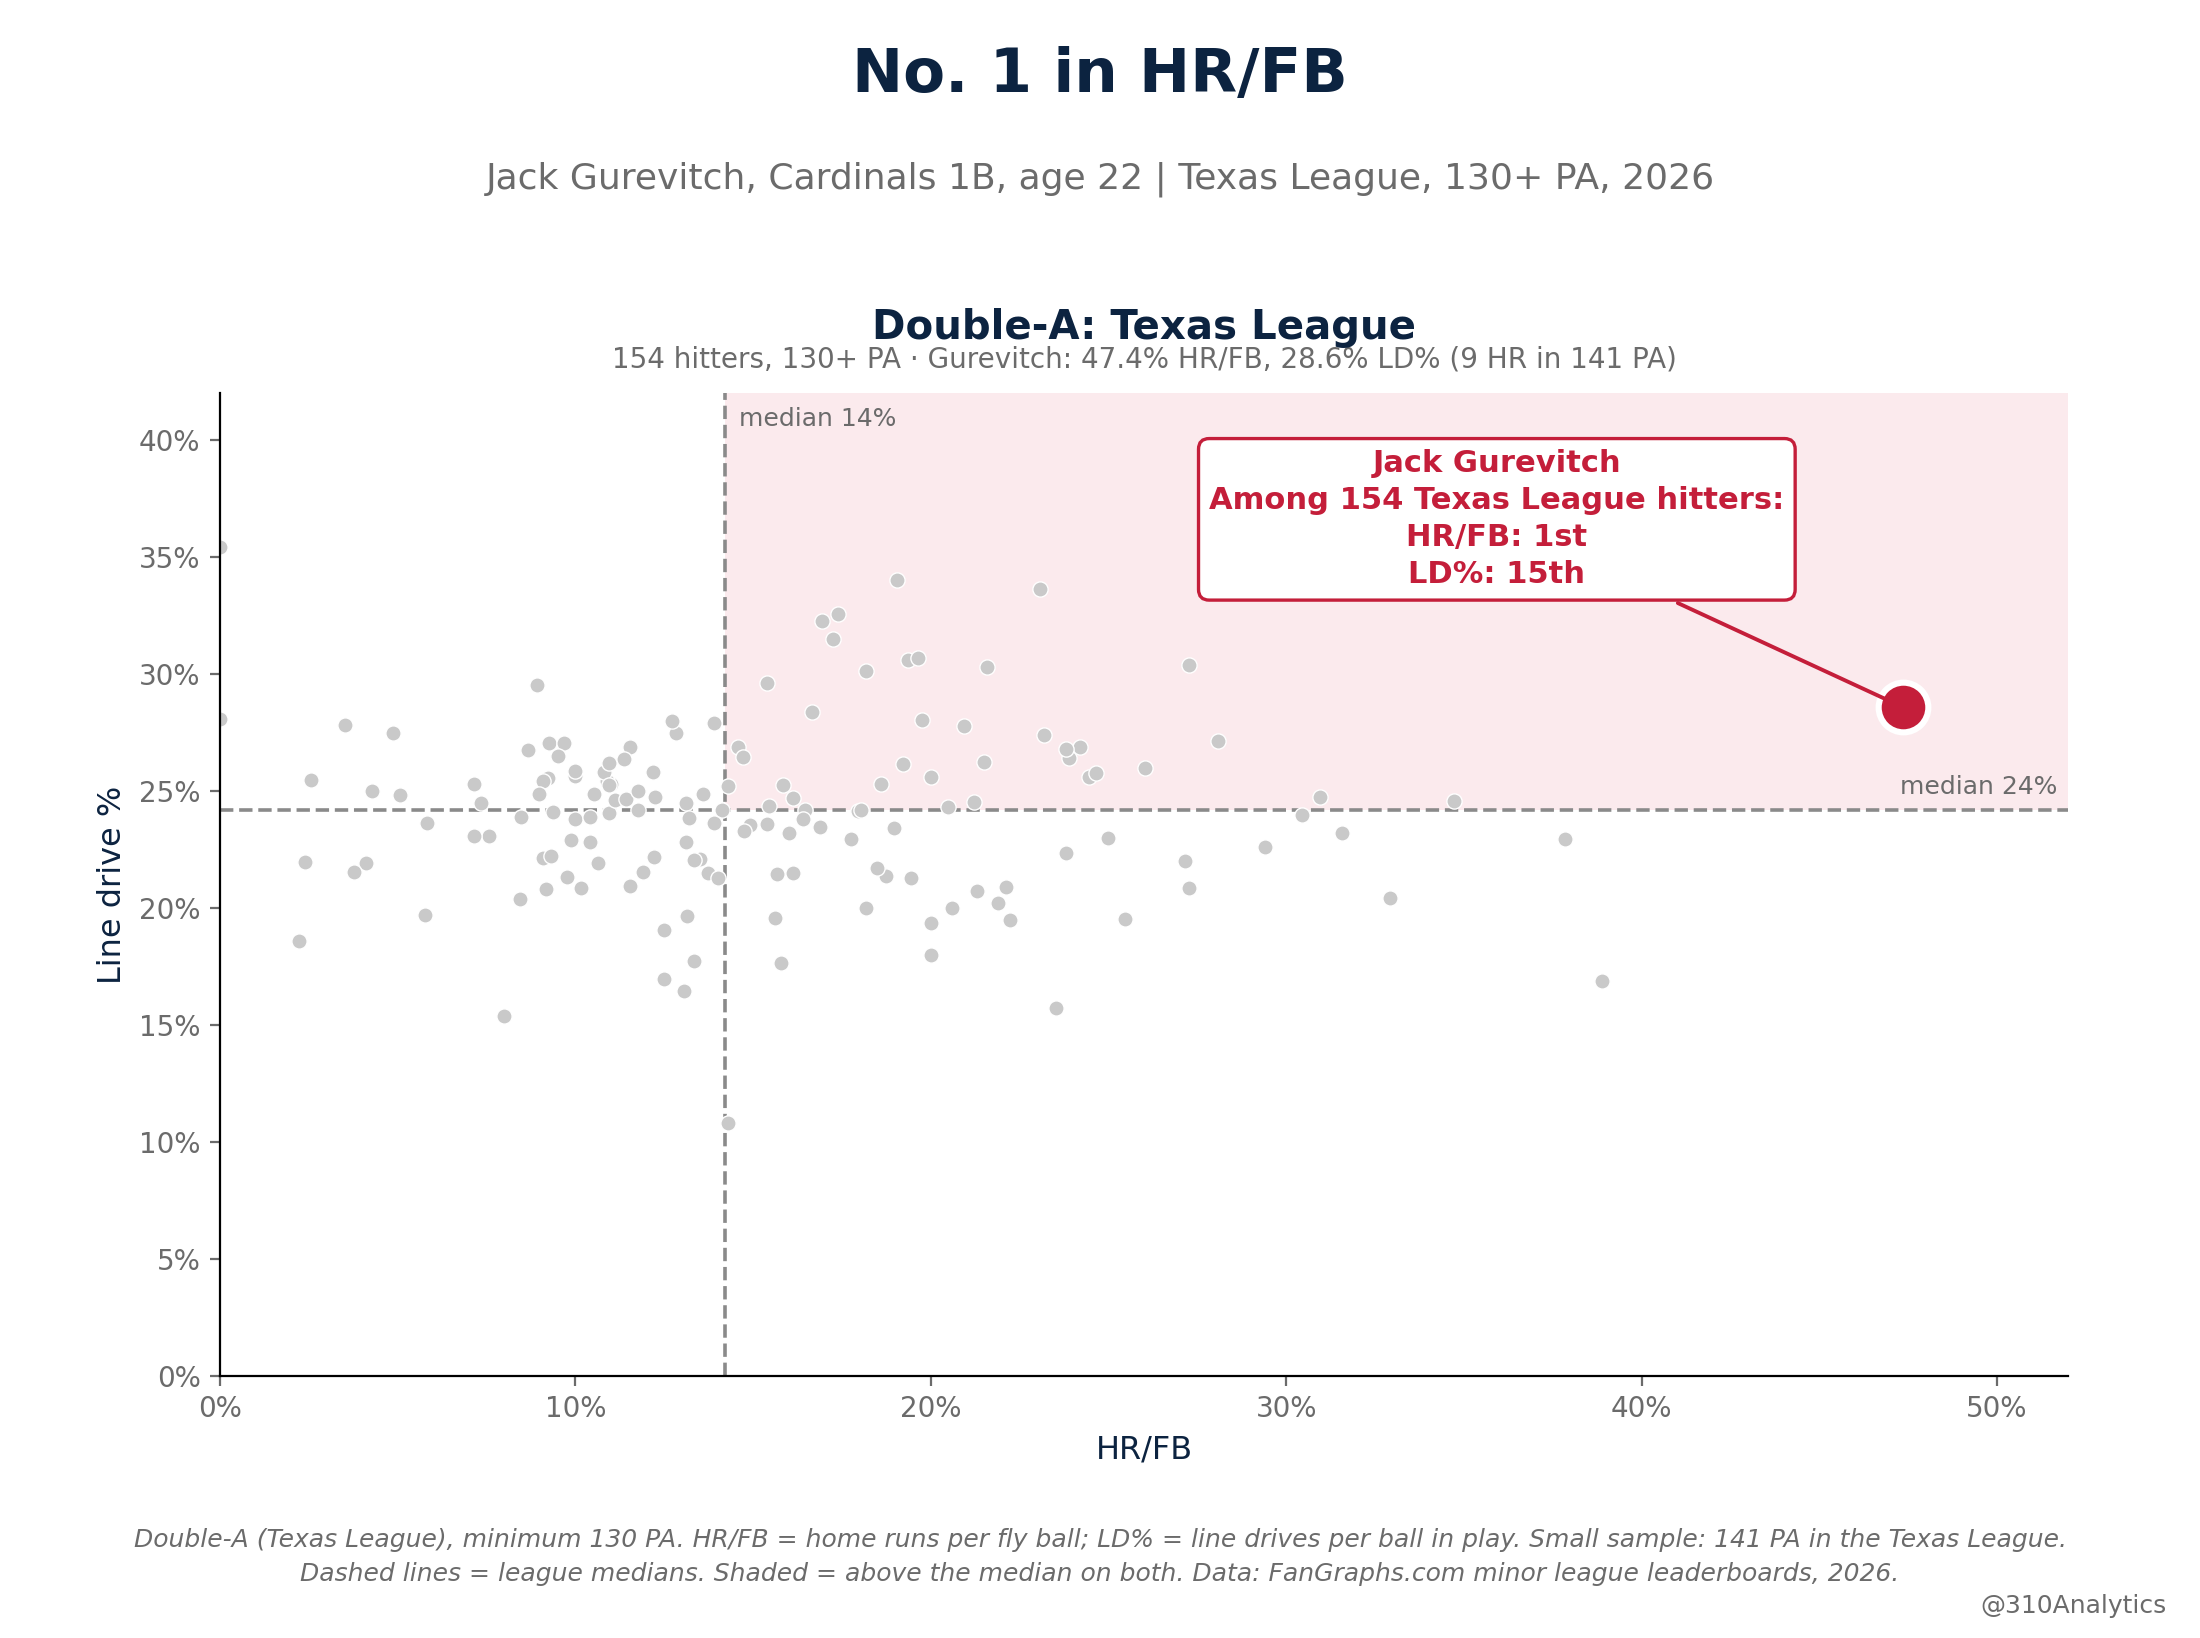

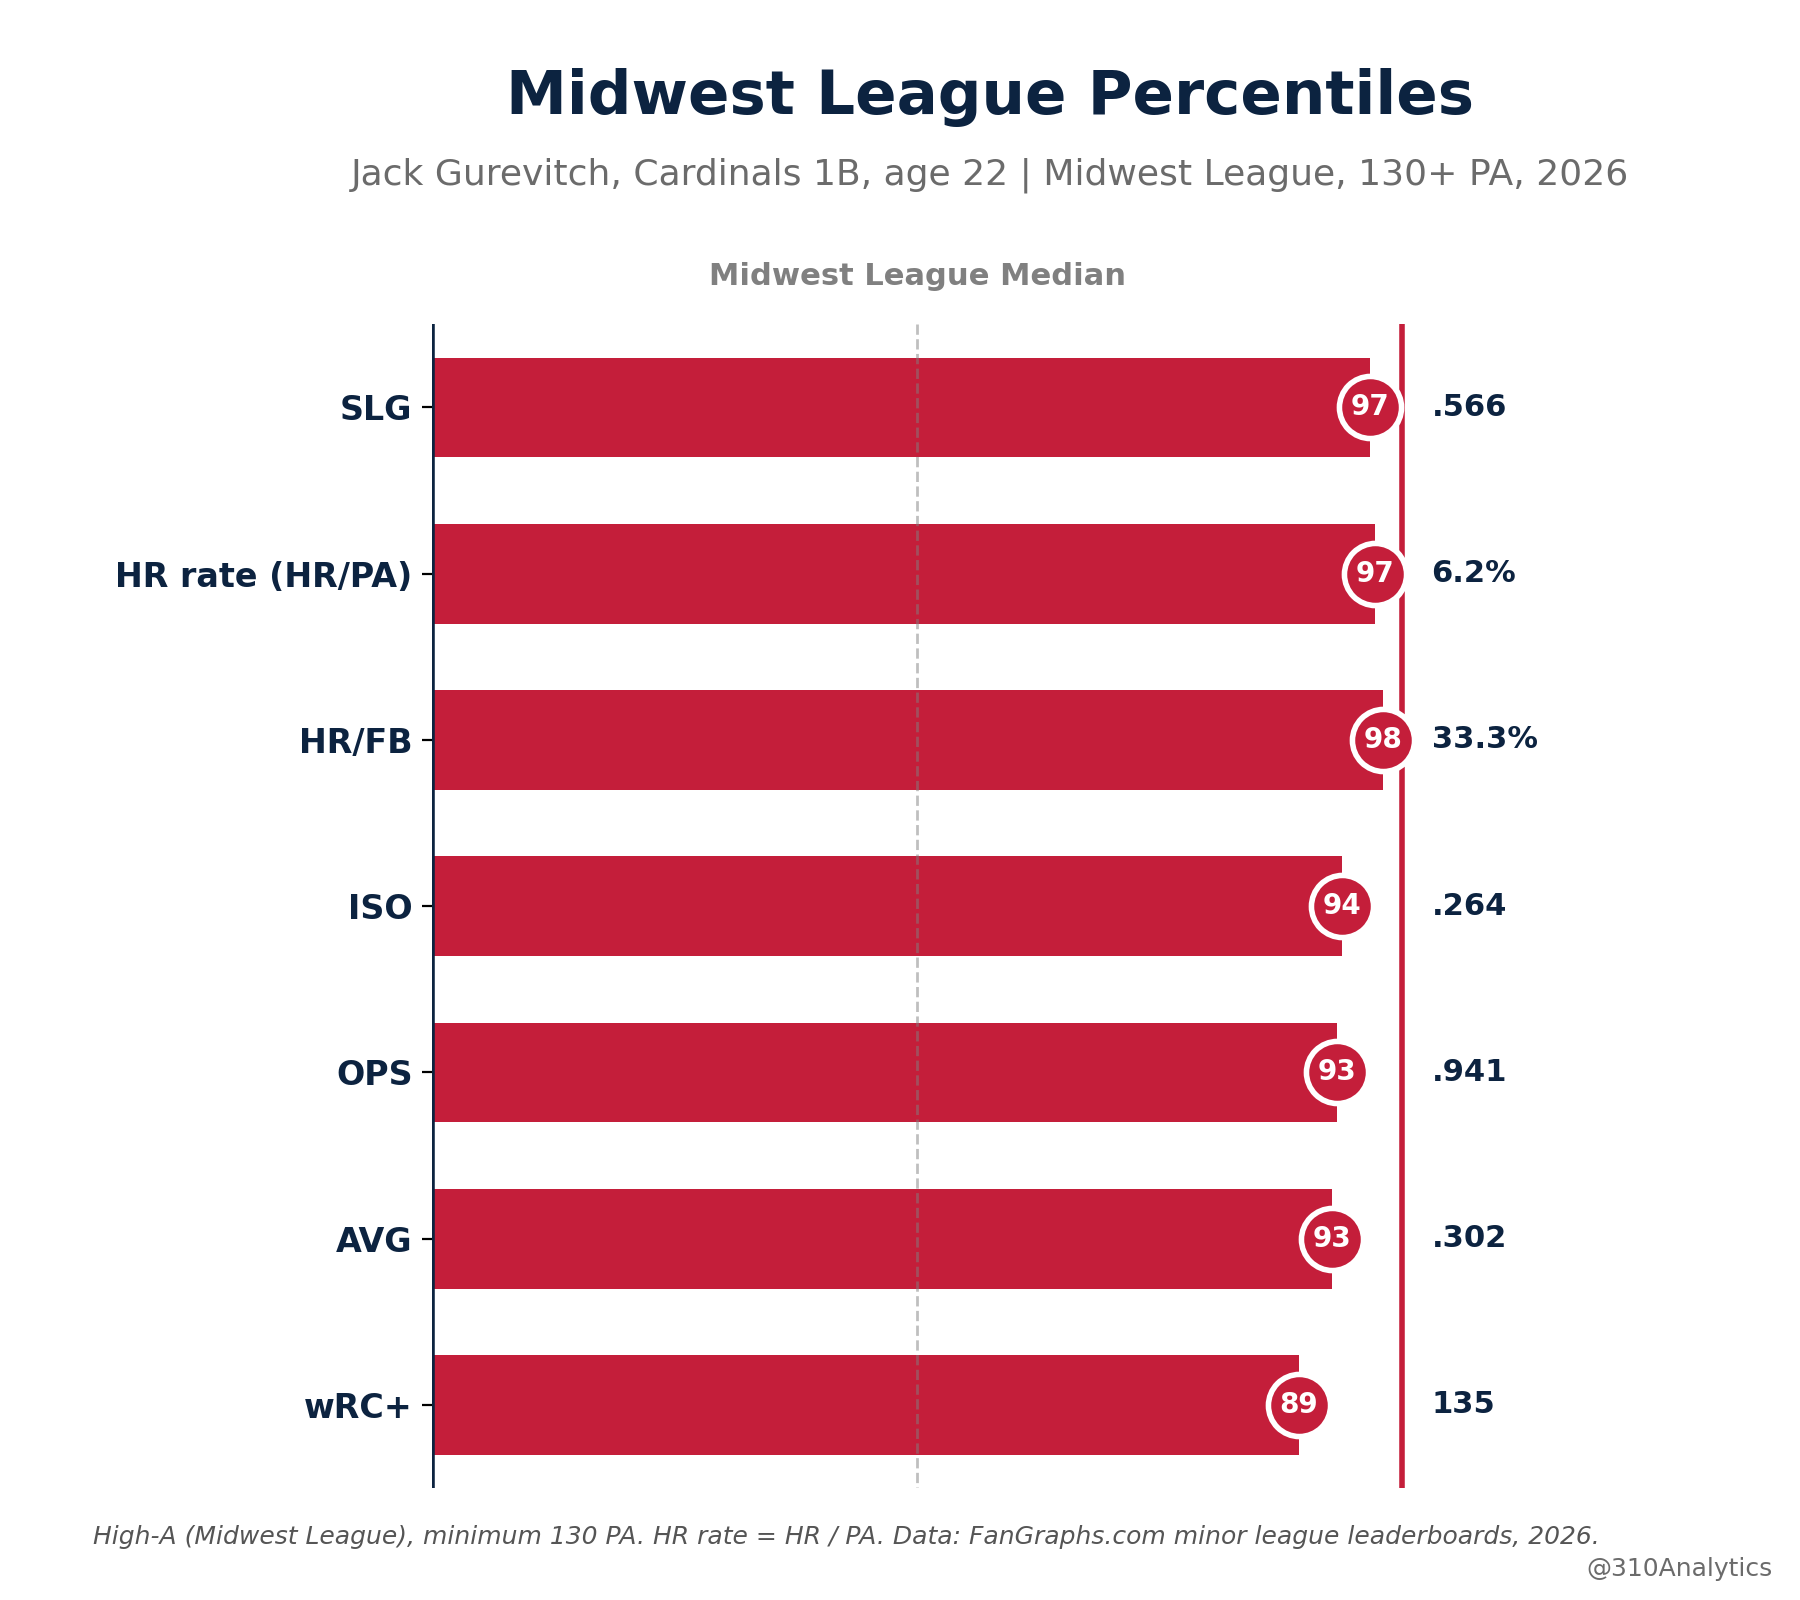

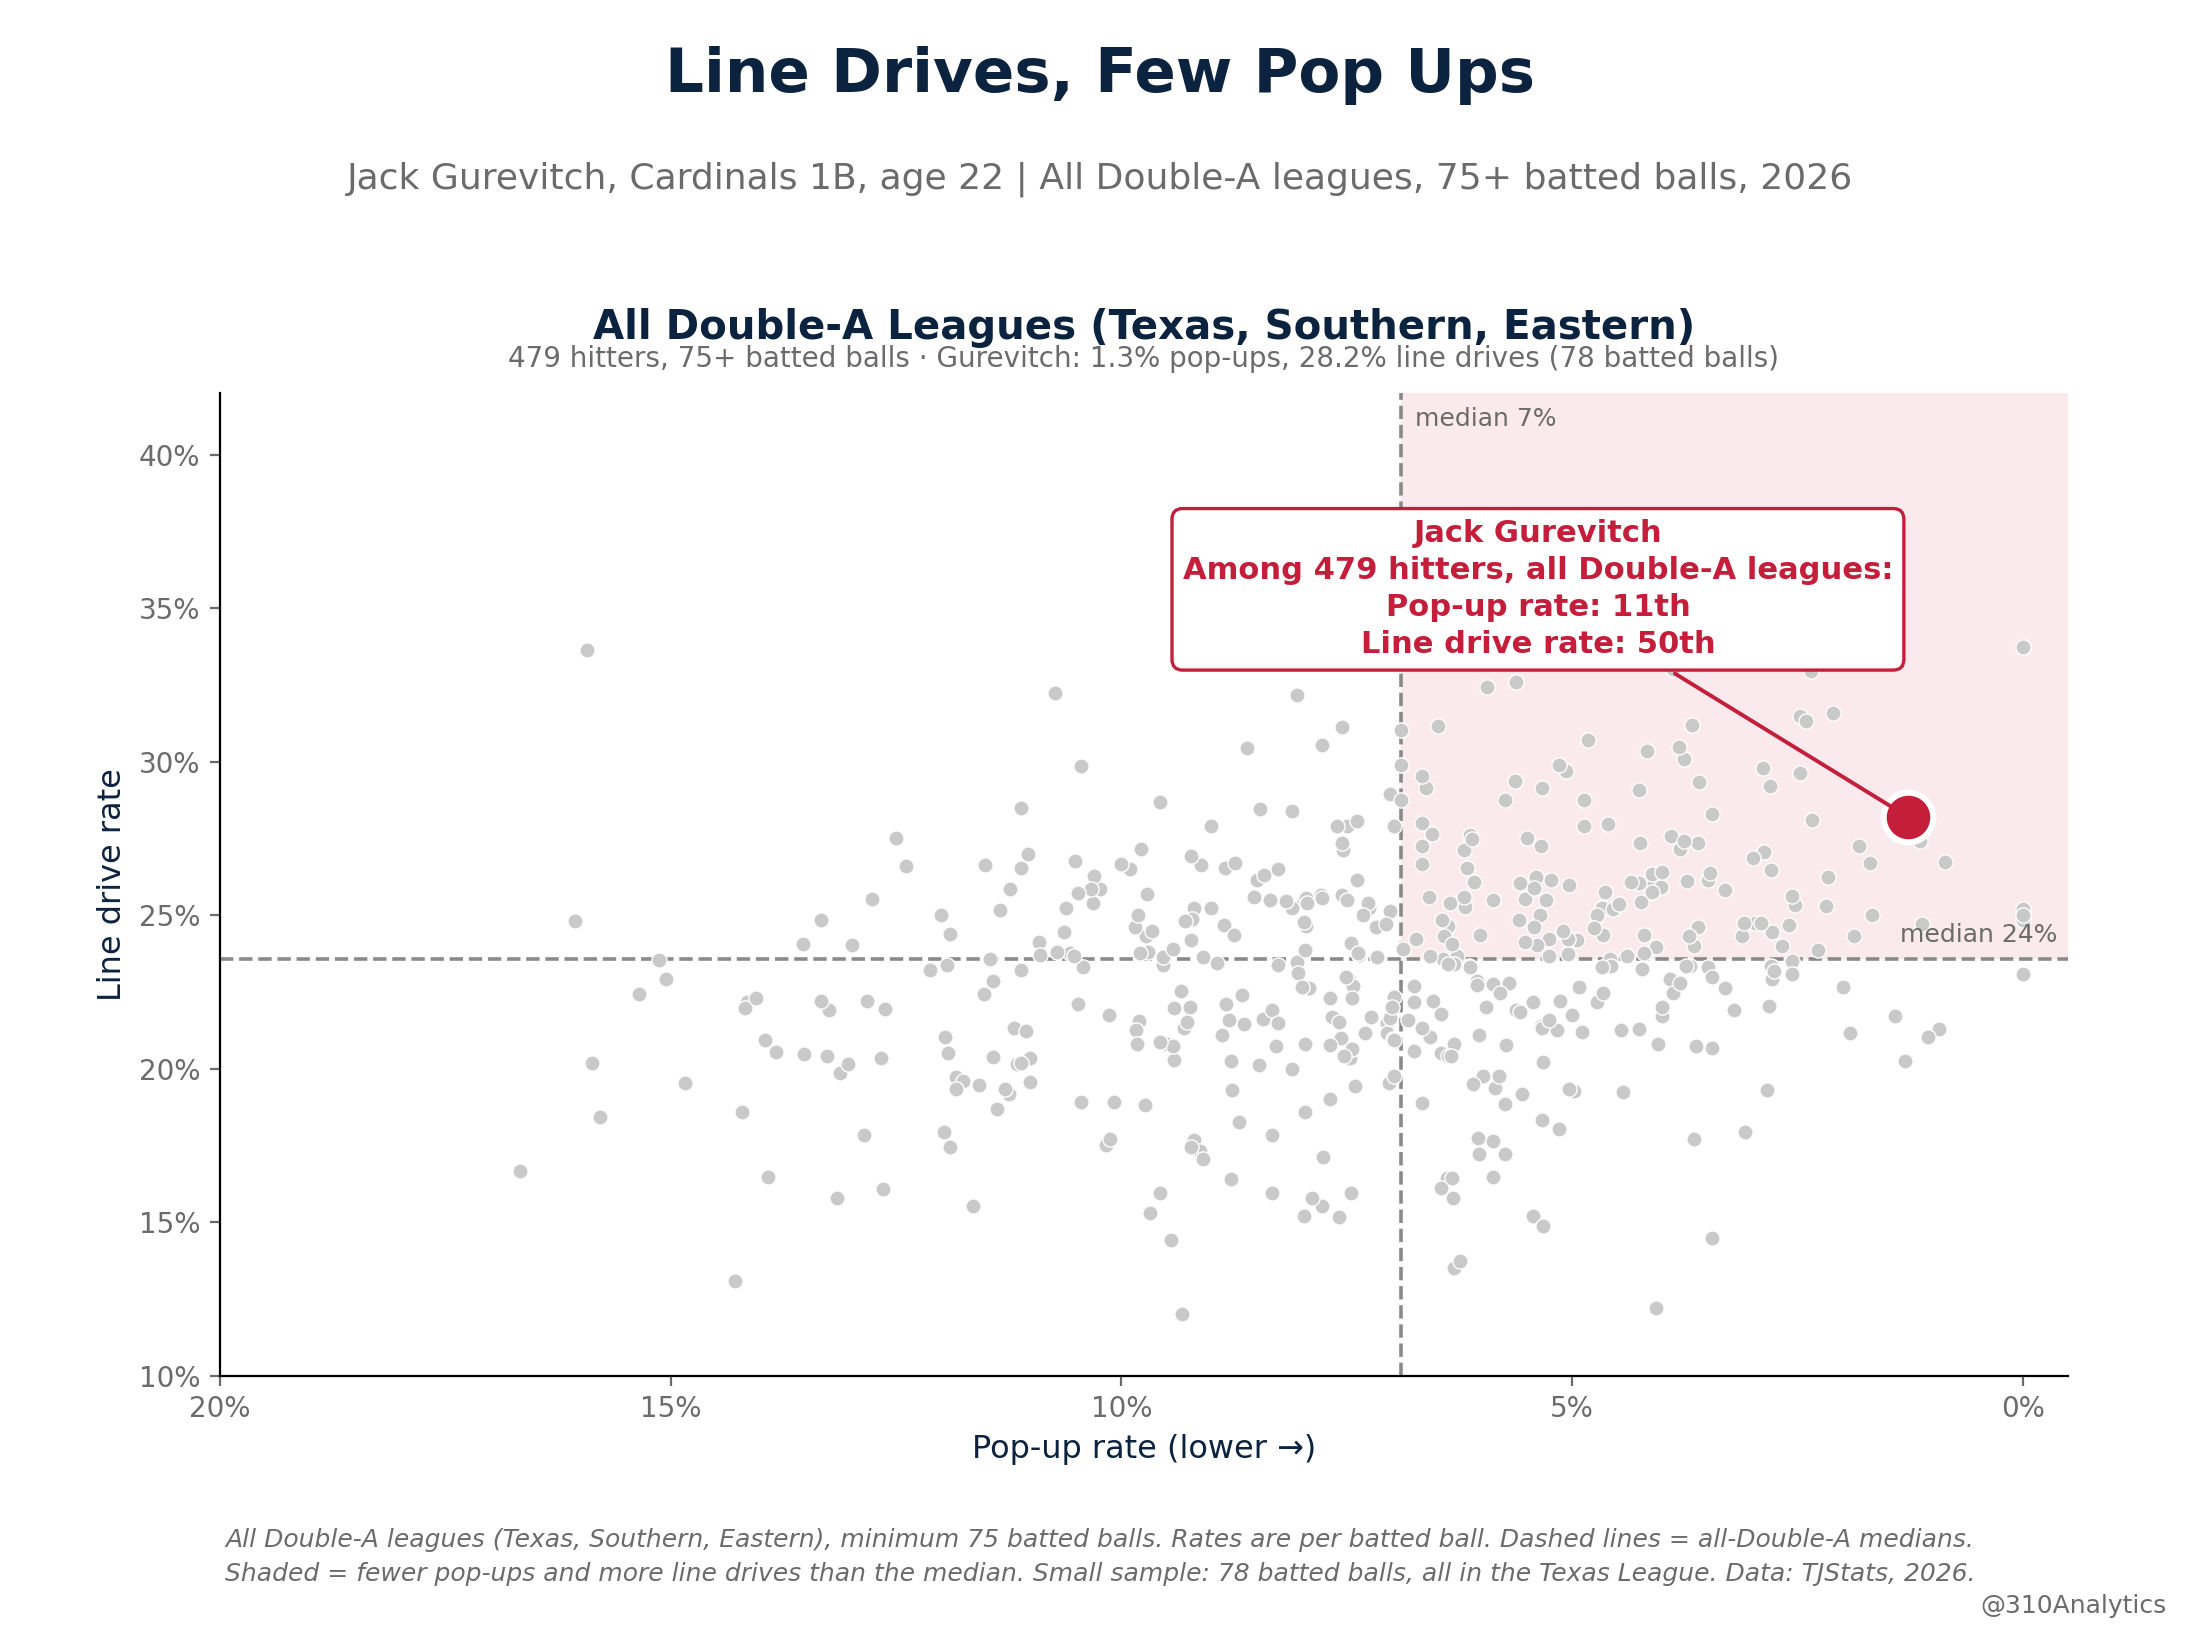

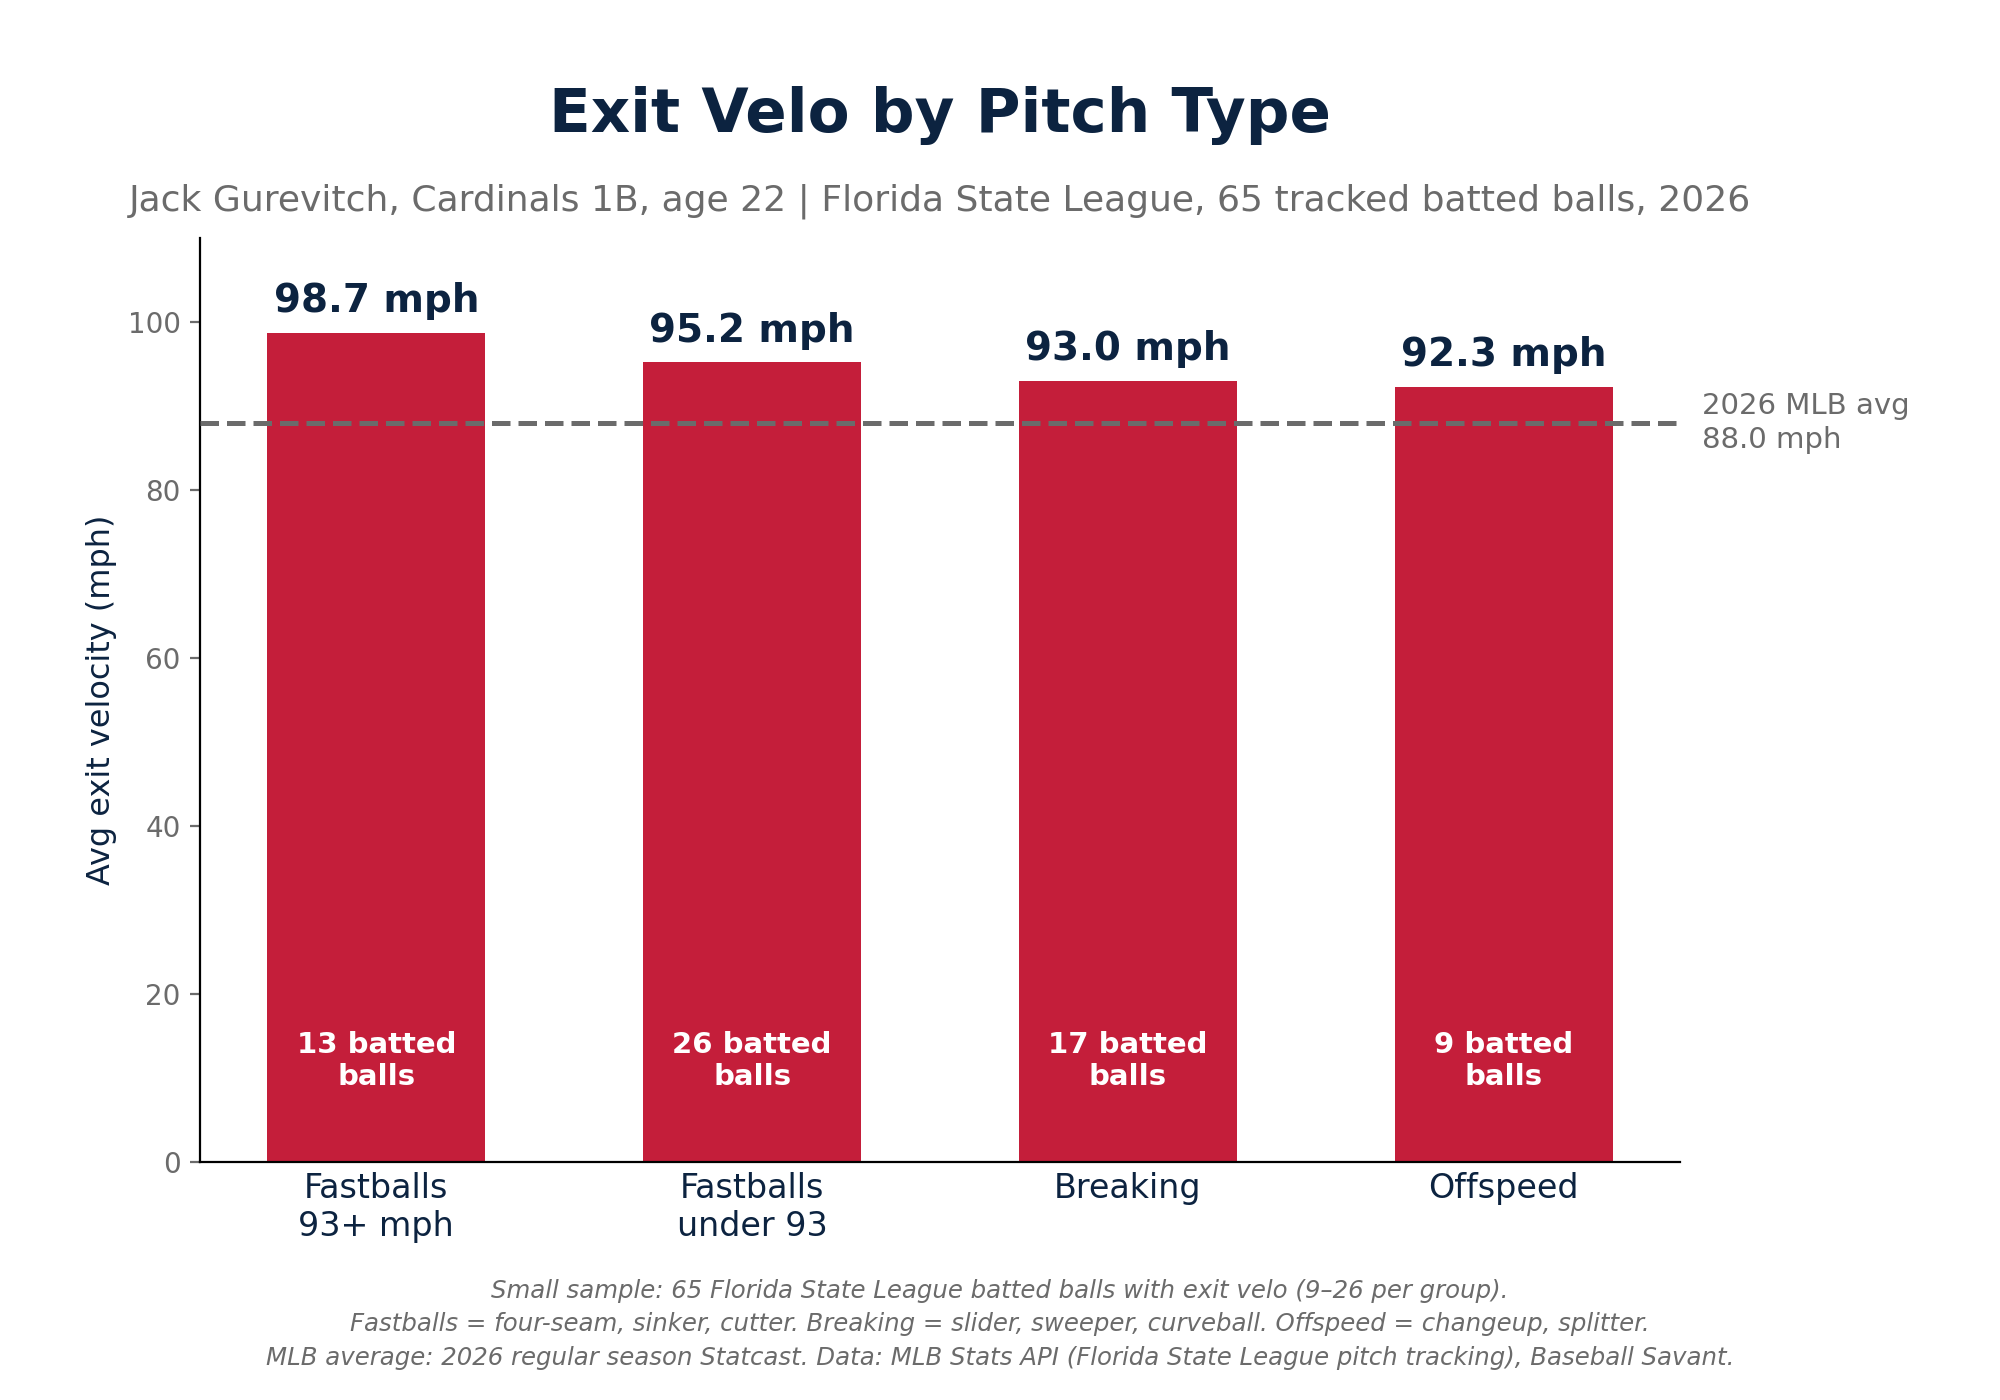

In [7]:
for f in charts.ALL:
    display(Image(filename=str(charts.FIG / f"gurevitch_{f.__name__}_2026.png"), width=800))